# import packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [ ]:
!pip install rpy2

In [ ]:
%load_ext rpy2.ipython

# Taguchi Design

***개념***

- 다양한 환경에서 최적의 품질을 유지할 수 있는 제어인자들의 조합을 찾는 방법
- 기존의 실험계획법들이 변수들의 평균값에 초점을 맞추었던 것과 달리, 다구찌 방법은 잡음 인자의 고려를 통하여 현실의 공정조건을 반영하였으며, 이러한 잡음 인자들에 둔감함 (또는 영향을 받지 않는) 조건을 찾음으로써 품질 손실을 감소시키는 최적의 조건을 찾아 낼 수 있다.

(잡음 인자 = 날씨, 제품의 고장 여부 등 Noise Factor 로 생산자가 조절할 수 없고, 소비자의 특성 또는 환경에 따라 변화할 수 있는 요인)


***SN 비***

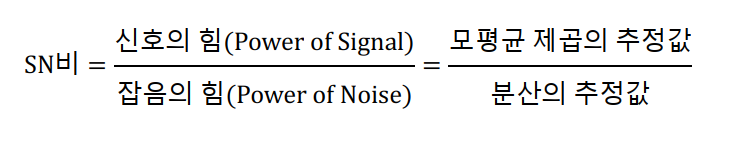

- 다구찌 방법에선 손실함수에 대한 정의를 통해 목표치와 출력값 차이만큼에 대응하는 손실의 크기를 측정할 수 있다.
- SN비는 "신호 대 잡음 비율"로써, 제품이나 서비스의 품질을 평가할때 신호(평균)과 잡음(산포)을 모두 고려한다.
- SN비는 신호는 극대화하고 잡음은 최소화 할 수 있는 조건을 찾아낼 수 있으며, 이를 통해 속성과 수준의 이상적인 조합을 찾아 품질을 최대화 할 수 있다.

***특성 설정***

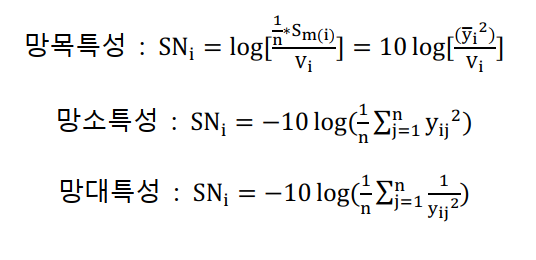

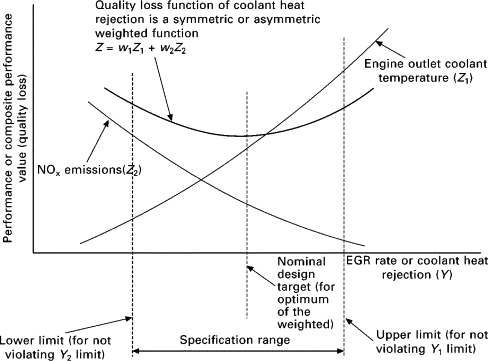

* 위 그래프 예시]
  y 축 = quality loss of engine (엔진의 품질 손실)

* y 인 품질을 어떤 특성으로 선택하는지가 중요합니다 (연구자 혹은 연구 목적마다 다를 수 있습니다!)


망소특성 = 출력값이 작을수록 품질 손실이 적음 = Engine outlet coolant temperature

망대특성 = 출력값이 클수록 품질 손실이 적음 = NOx emission

  - 망소특성이나 망대특성의 경우 실험을 통해 SN비를 구하고, ANOVA test를 통해 유의한 인자를 선택하게 되는데 이때 :
   - Significant Control Factor = significant factors for *SN ratios through ANOVA* = Find optimum condition for these factors (Maximizing SN ratio in case of 망대특성, and vice versa)
    - Insignificant Factor (기타제어인자) = other control factors
   유의한 인자는 산포제어인자 = 웨에 속하지 않는 인자 = Find optimum condition based on other consideration such as economy, operability and easiness


망목특성 = 설정한 특정 목표값에 가까울수록 품질 손실이 적음 = Coolant Heat

  - 망목특성의 경우, SN비가 분산의 크기에 큰 영향을 받기 때문에 y값의 평균이 반영이 잘 되지 않는다.
  - 이러한 문제를 해결하기 위해 민감도 (Sensitivity)라는 새로운 개념을 도입한다.
  - 실험을 통해 SN비를 구하고, ANOVA test를 통해 유의한 인자를 선택하게 되는데 이때:
    - Dispersion Control Factor (산포제어인자) = significant factors for *SN ratios through ANOVA* = Find the condition that maximizes the SN ratio
    - Mean adjustment Factor (평균조정인자) = significant factors for *sensitivities through ANOVA* = Find the condition that gives the closest estimated response to the target response value
      * If a factor is both dispersion control factor and mean adjustment factor, classify it as dispersion control factor.
    - Insignificant Factor (기타제어인자) = other control factors = 둘다에 속하지 않는 인자 = Find optimum condition based on other consideration such as economy, operability and easiness

망소특성 or 망대특성일 경우 :
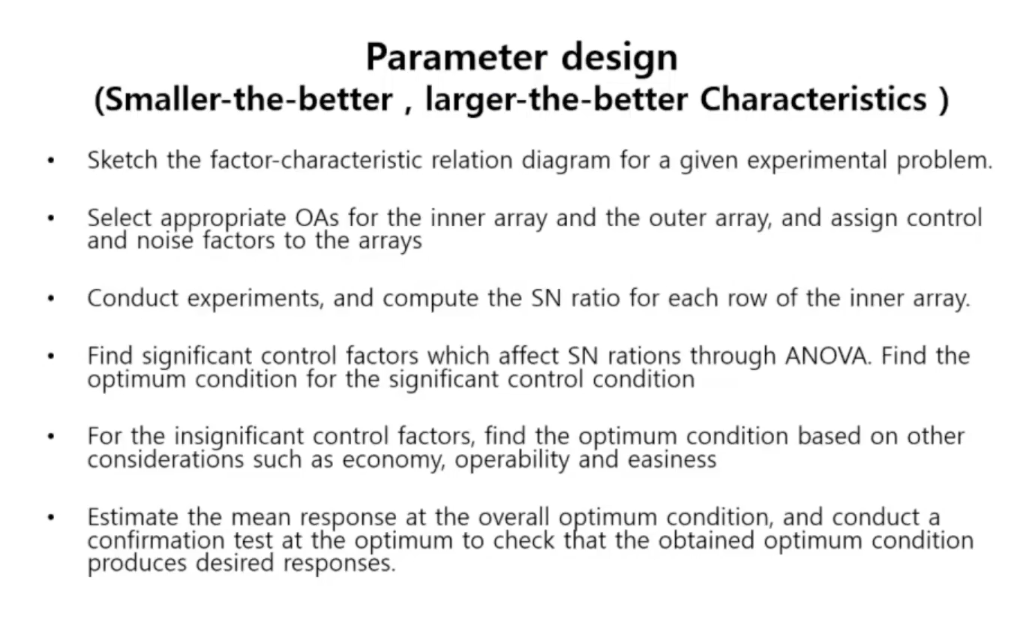

망목특성일 경우 :
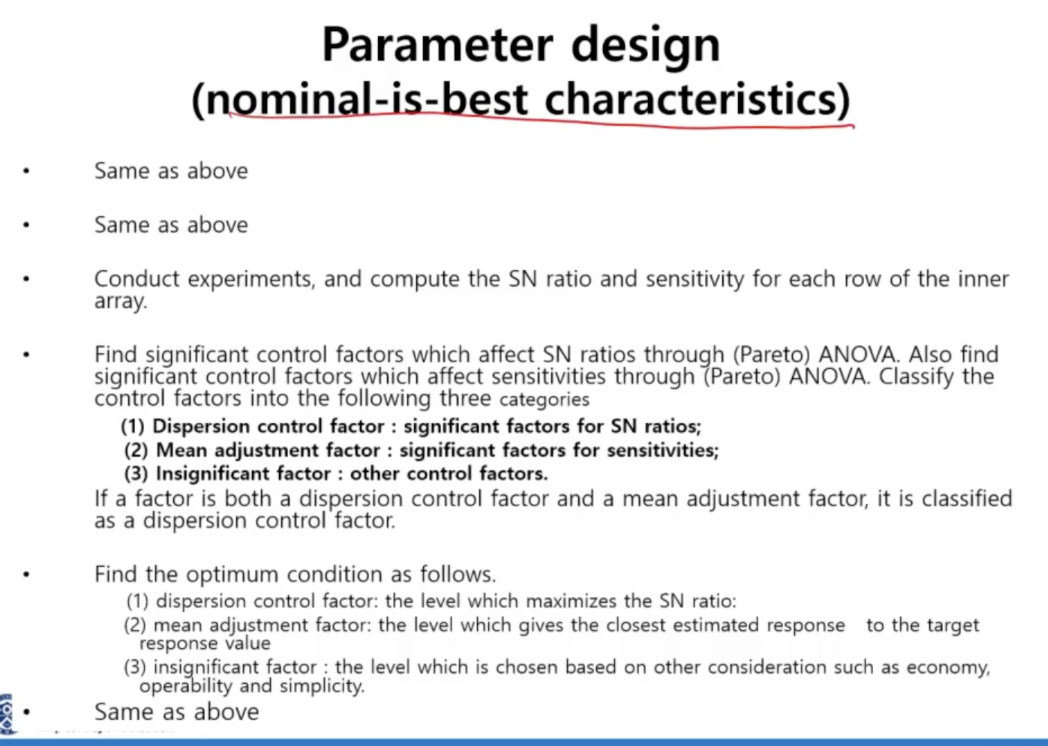

***Orthogonal Array (Inner & Outer Array + Control & Noise Factors to the arrays)***

- 인자가 많을 경우 큰 그물을 쳐서 "주효과"와 기술적으로 봤을때 있을것 같은 "2인자 교호작용"을 검출하고, 기술적으로 없을것이라 생각되는 "2인자 교호작용" 및 "고차의 교호작용"을 희생시켜 실험 횟수를 적게 할 수 있느 실험계획표

- 자세한 내용은 강의안 참조

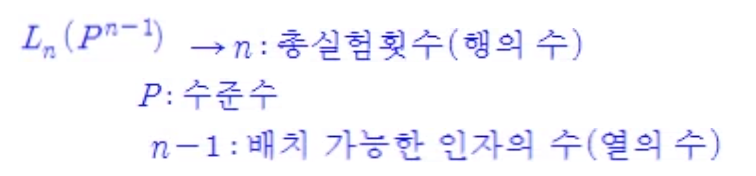

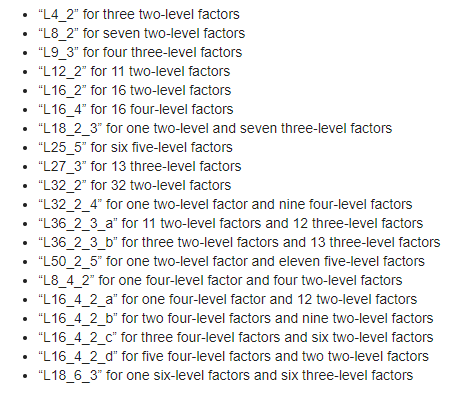

Ex) L4, 2^3
Factor(인자)의 수준이 2이며, 이러한 Factor가 3개일 경우, 실험을 4번 하도록 설계됨

(Full Factorial 일경우 8번, Orthogonal 일경우 4번)

Ex) 제어인자가 수준이 3개인게 4개, 수준이 2개인개 1개일 경우,

- Full Factorial 일경우 3^4*2^1 = 162번
- 최소 현재 자유도를 고려한 최소 실험 횟수 일경우 (3-1)*4+(2-1)*1 = 9번
- 1/9 Fractional Factorial 일경우 3^2*2^1 = 18번  

제어 인자 = Control Factor = 조절 가능한 변수

잡음 인자 = Noise Factor = 생산자가 조절할 수 없고, 소비자의 특성 또는 환경에 따라 변화할 수 있는 변수

Y = 품질 측정 기준


# 실습

## 1.속성 및 수준 정의

i) 제어 인자

In [ ]:
control=pd.DataFrame({'암출장치':['A1','A2',None],
                  '생산라인속도':['저속','중속','고속'],
                  '가열온도':['저온','보통','고온'],
                  '절연재료':['D1','D2','D3'],
                  'CV압력':['저압','중압','고압'],
                  'CV속도':['저속','중속','고속'],
                  '편조기장력':['낮다','보통','높다'],
                  '릴리즈도포':['l1','l2','l3']
                  })
control

,암출장치,생산라인속도,가열온도,절연재료,CV압력,CV속도,편조기장력,릴리즈도포
0,A1,저속,저온,D1,저압,저속,낮다,l1
1,A2,중속,보통,D2,중압,중속,보통,l2
2,None,고속,고온,D3,고압,고속,높다,l3


ii) 잡음 인자

In [ ]:
noise=pd.DataFrame({'작업샘플':['S1','S2'],
                  '샘플내의위치':['P1','P2']
                  })
noise

,작업샘플,샘플내의위치
0,S1,P1
1,S2,P2


## 2.직교 배열표 생성

제어인자의 수와 각 제어인자 수준에 따른 직교 배열표

In [ ]:
#Python은 orthogonal array를 제공하는 적절한 함수가 없으므로, R에서 추출
%%R

install.packages("devtools")
library(devtools)

install_url('https://cran.r-project.org/src/contrib/Archive/qualityTools/qualityTools_1.55.tar.gz')
install_url('https://cran.r-project.org/src/contrib/Archive/DoE.base/DoE.base_1.2.tar.gz')

library(qualityTools)
library(DoE.base)

###################################################
### Download R Studio and Run This Code there######
### 여기서 하면 안돌아갈 수도 있어요!           ###
###################################################

# Array 입력 #


# Inner array : Control Factor
## 각 변수들에 대해 이을 지정해주고(2^1,3^7), 18개의 직교 배열을 만듦 (18개인 이유는 위의 L 표 참조)
### 최소 현재 자유도를 고려한 최소 실험 횟수 = (3-1)*7+(2-1)*1 = 14번
control<-oa.design(nruns = 18,randomize=TRUE,factor.names = list(x1=c(1,2),x2=c(1,2,3),x3=c(1,2,3),x4=c(1,2,3),x5=c(1,2,3),x6=c(1,2,3),x7=c(1,2,3),x8=c(1,2,3)))

# Outer array : Noise Factor
## 4개의 직교배열표 만듬
noise<-oa.design(nruns=4,randomize=FALSE,factor.names = list(s=c(-1,1),p=c(-1,1)))

#Taguchi orthogonal array 생성
# inner array와 outer array를 결합함
## 18 * 4 = 72개로 이루어 져 있음
taguchi1<-param.design(control,noise,direction = "long", randomize=TRUE, responses='y')
write.csv(taguchi1,"/content/drive/MyDrive/Colab Notebooks/2. 품질공학/Taguchi.csv", row.names = TRUE)

R 에서 실행 후 해당 파일을 코랩 경로에 저장 후 불러오기



In [ ]:
design=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2. 품질공학/Taguchi.csv')
design=design.iloc[:,1:]
design

,x1,x2,x3,x4,x5,x6,x7,x8,s,p,y
0,1,1,1,1,1,1,1,1,-1,-1,NaN
1,1,1,1,1,1,1,1,1,1,-1,NaN
2,1,1,1,1,1,1,1,1,-1,1,NaN
3,1,1,1,1,1,1,1,1,1,1,NaN
4,1,1,1,2,2,3,3,2,-1,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
67,2,3,2,1,2,1,3,2,1,1,NaN
68,2,3,2,2,1,3,1,3,-1,-1,NaN
69,2,3,2,2,1,3,1,3,1,-1,NaN
70,2,3,2,2,1,3,1,3,-1,1,NaN


## 3.Y값 추가 및 Dataframe 재조정

In [ ]:
# Y 값 (Response) 입력
y=[20,33,16,59,40,14,25,10,33,53,45,22,60,22,48,10,40,29,111,20, 25,69,36,48,42,31,40,12,29,32,26,44,54,71,46,48,66,15,71,75,  47,44,75,79,62,78,80,65,36,12,23,16,49,87,50,70,46,65,55, 40,78,39,111,42,39,110,55,43,36,65,111,14]

Outer Array 에 따른 Dataframe 재조정

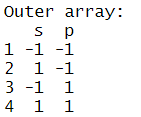

In [ ]:
taguchi=design.iloc[:,:-3]
taguchi=taguchi.drop_duplicates()
taguchi.reset_index(drop=True,inplace=True)
taguchi

,x1,x2,x3,x4,x5,x6,x7,x8
0,1,1,1,1,1,1,1,1
1,1,1,1,2,2,3,3,2
2,1,1,2,1,3,3,2,3
3,1,2,2,2,2,2,2,1
4,1,2,2,3,3,1,1,2
5,1,2,3,2,1,1,3,3
6,1,3,1,3,2,2,1,3
7,1,3,3,1,1,2,2,2
8,1,3,3,3,3,3,3,1
9,2,1,2,3,1,2,3,1


In [ ]:
#outer array
n=4

#각 outer array 별 실험 값 추출
y1=[y[i] for i in range(len(y)) if i%n==0]
y2=[y[i] for i in range(len(y))if i%n==1]
y3=[y[i] for i in range(len(y)) if i%n==2]
y4=[y[i] for i in range(len(y)) if i%n==3]

# 해당 실험 값을 알맞는 열에 삽입
taguchi['y1']=y1
taguchi['y2']=y2
taguchi['y3']=y3
taguchi['y4']=y4

#18개 실험으로 이루어진 직교배열표와, 각 실험에서 각 잡음인자일때의 Y 값
taguchi

,x1,x2,x3,x4,x5,x6,x7,x8,y1,y2,y3,y4
0,1,1,1,1,1,1,1,1,20,33,16,59
1,1,1,1,2,2,3,3,2,40,14,25,10
2,1,1,2,1,3,3,2,3,33,53,45,22
3,1,2,2,2,2,2,2,1,60,22,48,10
4,1,2,2,3,3,1,1,2,40,29,111,20
5,1,2,3,2,1,1,3,3,25,69,36,48
6,1,3,1,3,2,2,1,3,42,31,40,12
7,1,3,3,1,1,2,2,2,29,32,26,44
8,1,3,3,3,3,3,3,1,54,71,46,48
9,2,1,2,3,1,2,3,1,66,15,71,75


## 4.SN비 계산

### 0) mean and variable

In [ ]:
y_sum=taguchi.iloc[:,-n:].sum(axis=1)
y_mean=taguchi.iloc[:,-n:].mean(axis=1)
y_var=taguchi.iloc[:,-n:].var(axis=1)

In [ ]:
y_sum

0     128
1      89
2     153
3     140
4     200
5     178
6     125
7     131
8     219
9     227
10    245
11    285
12     87
13    256
14    206
15    270
16    247
17    226
dtype: int64

In [ ]:
y_mean

0     32.00
1     22.25
2     38.25
3     35.00
4     50.00
5     44.50
6     31.25
7     32.75
8     54.75
9     56.75
10    61.25
11    71.25
12    21.75
13    64.00
14    51.50
15    67.50
16    61.75
17    56.50
dtype: float64

In [ ]:
y_var

0      376.666667
1      180.250000
2      184.916667
3      529.333333
4     1720.666667
5      355.000000
6      187.583333
7       62.250000
8      128.916667
9      788.250000
10     334.916667
11      82.250000
12     110.916667
13     328.666667
14     119.000000
15    1155.000000
16    1080.916667
17    1756.333333
dtype: float64

In [ ]:
taguchi2 = taguchi.copy()
taguchi_base=taguchi2
#망목특성이라 아래 두개 열을 추가했으며, 다른 특성(예를 들어 망소특성)일 경우 해당하는 열(smaller_sn)을 추가하면 됨
taguchi_base['y_mean']=y_mean
taguchi_base

,x1,x2,x3,x4,x5,x6,x7,x8,y1,y2,y3,y4,y_mean
0,1,1,1,1,1,1,1,1,20,33,16,59,32.00
1,1,1,1,2,2,3,3,2,40,14,25,10,22.25
2,1,1,2,1,3,3,2,3,33,53,45,22,38.25
3,1,2,2,2,2,2,2,1,60,22,48,10,35.00
4,1,2,2,3,3,1,1,2,40,29,111,20,50.00
5,1,2,3,2,1,1,3,3,25,69,36,48,44.50
6,1,3,1,3,2,2,1,3,42,31,40,12,31.25
7,1,3,3,1,1,2,2,2,29,32,26,44,32.75
8,1,3,3,3,3,3,3,1,54,71,46,48,54.75
9,2,1,2,3,1,2,3,1,66,15,71,75,56.75


### 1) 망대특성

In [ ]:
larger_sn=-10*np.log10((1/len(y_mean))*(1/(taguchi.iloc[:,-n:]**2).sum(axis=1)))

In [ ]:
larger_sn

0     49.734419
1     46.568454
2     50.619272
3     50.673833
4     54.360290
5     52.088389
6     49.054829
7     49.062596
8     53.478879
9     54.384569
10    54.596910
11    55.681477
12    46.026025
13    54.950723
14    52.953207
15    55.915321
16    55.223268
17    55.114609
dtype: float64

### 2) 망소특성

In [ ]:
smaller_sn=-10*np.log10((1/len(y_mean))*((taguchi.iloc[:,-n:]**2).sum(axis=1)))

In [ ]:
smaller_sn

0    -24.628969
1    -21.463003
2    -25.513822
3    -25.568383
4    -29.254840
5    -26.982939
6    -23.949378
7    -23.957146
8    -28.373429
9    -29.279119
10   -29.491460
11   -30.576027
12   -20.920575
13   -29.845273
14   -27.847757
15   -30.809870
16   -30.117818
17   -30.009159
dtype: float64

### 3) 망목특성

i) SN비

In [ ]:
nominal_sn=10*np.log10((y_mean)**2/y_var)

In [ ]:
nominal_sn

0      4.343428
1      4.387848
2      8.982868
3      3.644068
4      1.622433
5      7.464917
6      7.165058
7     12.362833
8     13.664592
9      6.112678
10    10.492754
11    17.904338
12     6.299217
13    10.956043
14    13.480675
15     5.960256
16     5.474817
17     2.594900
dtype: float64

ii) sensitivity

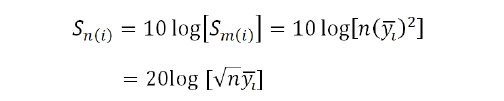

In [ ]:
sensitivity=20*np.log10(np.sqrt(n)*y_mean)

In [ ]:
sensitivity

0     36.123599
1     32.967200
2     37.673229
3     36.901961
4     40.000000
5     38.987800
6     35.917600
7     36.324826
8     40.788282
9     41.099917
10    41.762722
11    43.076297
12    32.769785
13    42.144199
14    40.256744
15    42.606675
16    41.833339
17    41.061569
dtype: float64

## 5.Parameter 디자인 (ex 망목특성)

In [ ]:
taguchi_nominal=taguchi
#망목특성이라 아래 두개 열을 추가했으며, 다른 특성(예를 들어 망소특성)일 경우 해당하는 열(smaller_sn)을 추가하면 됨
taguchi_nominal['nominal_sn']=nominal_sn
taguchi_nominal['sensitivity']=sensitivity
taguchi_nominal

,x1,x2,x3,x4,x5,x6,x7,x8,y1,y2,y3,y4,nominal_sn,sensitivity
0,1,1,1,1,1,1,1,1,20,33,16,59,4.343428,36.123599
1,1,1,1,2,2,3,3,2,40,14,25,10,4.387848,32.967200
2,1,1,2,1,3,3,2,3,33,53,45,22,8.982868,37.673229
3,1,2,2,2,2,2,2,1,60,22,48,10,3.644068,36.901961
4,1,2,2,3,3,1,1,2,40,29,111,20,1.622433,40.000000
5,1,2,3,2,1,1,3,3,25,69,36,48,7.464917,38.987800
6,1,3,1,3,2,2,1,3,42,31,40,12,7.165058,35.917600
7,1,3,3,1,1,2,2,2,29,32,26,44,12.362833,36.324826
8,1,3,3,3,3,3,3,1,54,71,46,48,13.664592,40.788282
9,2,1,2,3,1,2,3,1,66,15,71,75,6.112678,41.099917


### 1) SN비 ANOVA

In [ ]:
model=ols('nominal_sn~x1+x2+x3+x4+x5+x6+x7+x8',data=taguchi_nominal).fit()
anova_table=anova_lm(model,typ=1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
x1,1.0,13.585311,13.585311,0.656799,0.438596
x2,1.0,2.084549,2.084549,0.100780,0.758137
x3,1.0,109.555117,109.555117,5.296580,0.046890
x4,1.0,3.500608,3.500608,0.169241,0.690411
x5,1.0,0.846586,0.846586,0.040929,0.844174
x6,1.0,10.634689,10.634689,0.514147,0.491538
x7,1.0,1.143808,1.143808,0.055299,0.819350
x8,1.0,0.856324,0.856324,0.041400,0.843294
Residual,9.0,186.157100,20.684122,NaN,NaN


In [ ]:
# 제어 인자 참조
control

,암출장치,생산라인속도,가열온도,절연재료,CV압력,CV속도,편조기장력,릴리즈도포
0,A1,저속,저온,D1,저압,저속,낮다,l1
1,A2,중속,보통,D2,중압,중속,보통,l2
2,None,고속,고온,D3,고압,고속,높다,l3


i) 산포제어인자 해석

x3 (C=가열온도) 만 유의수준 0.05 미만에서 산포제어인자로써 통계적으로 유의하다고 도출됨

ii)

ANOVA 를 통해 확인한 인자수준별 SN비 통계량

In [ ]:
x=8 #속성의 갯수
factor_sum=[]
factor_mean=[]
for i in range(x):
  grouped=taguchi_nominal['nominal_sn'].groupby(taguchi_nominal.iloc[:,i])
  factor_sum.append(list(grouped.sum()))
  factor_mean.append(list(grouped.mean()))

In [ ]:
sn_sum=pd.DataFrame(factor_sum).transpose()
sn_sum.columns=['A','B','C','D','E','F','G','H']
sn_sum

,A,B,C,D,E,F,G,H
0,63.638044,52.223914,39.111849,50.943838,43.834797,42.770188,39.699247,47.205696
1,79.275677,43.467353,28.431763,34.544742,52.056804,46.076608,59.810406,45.296727
2,NaN,47.222455,75.370109,57.425141,47.022120,54.066925,43.404068,50.411298


In [ ]:
sn_mean=pd.DataFrame(factor_mean).transpose()
sn_mean.columns=['A','B','C','D','E','F','G','H']
sn_mean

,A,B,C,D,E,F,G,H
0,7.070894,8.703986,6.518641,8.490640,7.305799,7.128365,6.616541,7.867616
1,8.808409,7.244559,4.738627,5.757457,8.676134,7.679435,9.968401,7.549454
2,NaN,7.870409,12.561685,9.570857,7.837020,9.011154,7.234011,8.401883


In [ ]:
total_SN_mean_1=sn_mean['A'].mean()
total_SN_mean_2=sn_mean['H'].mean()
print(total_SN_mean_1,total_SN_mean_2)

7.939651156870484 7.939651156870485


- Dispersion Control Factor (산포제어인자) = significant factors for SN ratios through ANOVA = Find the condition that maximizes the SN ratio

- C(가열온도)는 SN비에 의해 Dispersion Control Factor 로 통계적 유의성이 검증된 만큼, C(가열온도)의 수준은 SN비의 합계와 평균이 최대화 되도록 해주는 조합인 2수준 (고온)이 선택되어야 한다 --> C2

In [ ]:
# 제어 인자 참조
control

,암출장치,생산라인속도,가열온도,절연재료,CV압력,CV속도,편조기장력,릴리즈도포
0,A1,저속,저온,D1,저압,저속,낮다,l1
1,A2,중속,보통,D2,중압,중속,보통,l2
2,None,고속,고온,D3,고압,고속,높다,l3


### 2) Sensitivity ANOVA

In [ ]:
model=ols('sensitivity~x1+x2+x3+x4+x5+x6+x7+x8',data=taguchi_nominal).fit()
aov_table=anova_lm(model,typ=1)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
x1,1.0,53.136884,53.136884,9.694133,0.012448
x2,1.0,2.831755,2.831755,0.516617,0.490527
x3,1.0,29.039979,29.039979,5.297966,0.046866
x4,1.0,27.134488,27.134488,4.950334,0.053134
x5,1.0,0.001662,0.001662,0.000303,0.986488
x6,1.0,4.987770,4.987770,0.909954,0.365043
x7,1.0,3.713982,3.713982,0.677568,0.431695
x8,1.0,5.728251,5.728251,1.045045,0.333342
Residual,9.0,49.332103,5.481345,NaN,NaN


In [ ]:
control

,암출장치,생산라인속도,가열온도,절연재료,CV압력,CV속도,편조기장력,릴리즈도포
0,A1,저속,저온,D1,저압,저속,낮다,l1
1,A2,중속,보통,D2,중압,중속,보통,l2
2,None,고속,고온,D3,고압,고속,높다,l3


i) 해석

x1 (A=암출장치), x3 (C=가열온도), x4 (D=절연재료) 만 유의수준 0.1 미만에서 평균조정인자로써 통계적으로 유의하다고 도출됨

* If a factor is both dispersion control factor and mean adjustment factor, classify it as dispersion control factor.
* 따라서 x1 (A=암출장치)와 x4 (D=절연재료)만 평균조정인자로 판단함

ii)

ANOVA 를 통해 확인한 인자수준별 Sensitivity 통계량

In [ ]:
#Sensitivity

x=8 #속성 갯수
factor_sums=[]
factor_means=[]
for i in range(x):
  grouped=taguchi_nominal['sensitivity'].groupby(taguchi_nominal.iloc[:,i])
  factor_sums.append(list(grouped.sum()))
  factor_means.append(list(grouped.mean()))

In [ ]:
se_sum=pd.DataFrame(factor_sums).transpose()
se_sum.columns=['A','B','C','D','E','F','G','H']
se_sum

,A,B,C,D,E,F,G,H
0,335.684498,232.702965,222.529060,224.981523,235.741911,242.627711,235.122235,237.777180
1,366.611249,231.060490,238.570015,234.287927,230.953142,224.776811,238.727188,235.032287
2,NaN,238.532292,241.196672,243.026297,235.600693,234.891224,228.446324,229.486280


In [ ]:
se_mean=pd.DataFrame(factor_means).transpose()
se_mean.columns=['A','B','C','D','E','F','G','H']
se_mean

,A,B,C,D,E,F,G,H
0,37.298278,38.783827,37.088177,37.496920,39.290319,40.437952,39.187039,39.629530
1,40.734583,38.510082,39.761669,39.047988,38.492190,37.462802,39.787865,39.172048
2,NaN,39.755382,40.199445,40.504383,39.266782,39.148537,38.074387,38.247713


In [ ]:
# y mean -> 이걸 사용해야 합니다

#this used taguchi_base, 위에서 만들었습니다!
x=8 #속성 갯수
factor_sums=[]
factor_means=[]
for i in range(x):
  grouped=taguchi_base['y_mean'].groupby(taguchi_base.iloc[:,i])
  factor_sums.append(list(grouped.sum()))
  factor_means.append(list(grouped.mean()))
y_mean_sum=pd.DataFrame(factor_sums).transpose()
y_mean_sum.columns=['A','B','C','D','E','F','G','H']
y_mean_sum

,A,B,C,D,E,F,G,H
0,340.75,281.75,238.75,238.0,286.5,327.00,282.50,297.5
1,512.25,266.75,298.25,287.0,273.0,238.75,308.75,292.0
2,NaN,304.50,316.00,328.0,293.5,287.25,261.75,263.5


In [ ]:
y_mean_mean=pd.DataFrame(factor_means).transpose()
y_mean_mean.columns=['A','B','C','D','E','F','G','H']
y_mean_mean

,A,B,C,D,E,F,G,H
0,37.861111,46.958333,39.791667,39.666667,47.750000,54.500000,47.083333,49.583333
1,56.916667,44.458333,49.708333,47.833333,45.500000,39.791667,51.458333,48.666667
2,NaN,50.750000,52.666667,54.666667,48.916667,47.875000,43.625000,43.916667


In [ ]:
total_mean_1=y_mean_mean['A'].mean()
total_mean_2=y_mean_mean['H'].mean()
print(total_mean_1,total_mean_2)

47.388888888888886 47.388888888888886


- Mean adjustment Factor (평균조정인자) = significant factors for *sensitivities through ANOVA* = Find the condition that gives the closest estimated response to the target response value (y_mean)


- x1 (A=암출장치)와 x4 (D=절연재료)는 Sensitivity에 의해 Mean adjustment Factor로 통계적 유의성이 검증된 만큼, x1 (A=암출장치)와 x4 (D=절연재료)의 수준은 평균이 설정된 target response 인 40 (교재 및 동영상 강의안 중반부분 참조)에 최대한 가깝게 되도록 해주는 조합을 찾아야 한다
- 이때 인자들의 수준의 평균이 47.39 [예를 들어 (49.58+48.67+43.92)/3=47.39이며]인 만큼, 37.86+47.83-47.39 = 38.3 이라 x1 (A=암출장치) = 0수준(A1), x4 (D=절연재료) = 1수준(D2)이 선택되어야 한다 --> A0, D1

In [ ]:
# 제어 인자 참조
control

,암출장치,생산라인속도,가열온도,절연재료,CV압력,CV속도,편조기장력,릴리즈도포
0,A1,저속,저온,D1,저압,저속,낮다,l1
1,A2,중속,보통,D2,중압,중속,보통,l2
2,None,고속,고온,D3,고압,고속,높다,l3


### 3) 결과 종합

- Insignificant Factor (기타제어인자) = other control factors = 둘다에 속하지 않는 인자 = Find optimum condition based on other consideration such as economy, operability and easiness

- 앞에서 검증한 A, C와 D를 제외한 나머지 제어 인자는 SN비나 Sensitivity에 유의한 영향을 미치지 못하는 기타제어인자로, 이들은 경제적 요건이나 쉬움 등을 고려하여 선정하면 된다.

--> A0 B0 C2 D1 E0 F0 G0 H0

In [ ]:
sn_mean

,A,B,C,D,E,F,G,H
0,7.070894,8.703986,6.518641,8.490640,7.305799,7.128365,6.616541,7.867616
1,8.808409,7.244559,4.738627,5.757457,8.676134,7.679435,9.968401,7.549454
2,NaN,7.870409,12.561685,9.570857,7.837020,9.011154,7.234011,8.401883


In [ ]:
#SN비 계산
7.070894+8.703986+12.561685+8.490640+7.305799+7.128365+6.616541+7.867616-7*total_SN_mean_2

10.1679679019066

In [ ]:
y_mean_mean

,A,B,C,D,E,F,G,H
0,37.861111,46.958333,39.791667,39.666667,47.750000,54.500000,47.083333,49.583333
1,56.916667,44.458333,49.708333,47.833333,45.500000,39.791667,51.458333,48.666667
2,NaN,50.750000,52.666667,54.666667,48.916667,47.875000,43.625000,43.916667


In [ ]:
#mean y 계산
37.861111+46.958333+52.666667+47.833333+47.750000+54.500000+47.083333+49.583333-7*total_mean_2

52.51388777777777

- 평균값이 52.513888이므로 40 +-15에 근접해 있어 규격을 만족
- SN비가 높아서 (10.16797) 잡음 인자의 영향을 적게 받는 조건

--> 전반적으로 규격 조건을 만족하는 양호한 조건